<a href="https://www.kaggle.com/code/seuwenfei/online-payment-fraud-detection?scriptVersionId=127055269" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# <div style='background:darkblue'>  <font color='white'>  <b>&nbsp;Introduction</b> </font> </div>


Online payment is the most popular transaction method in the world today. However, with an increase in online payments also comes a rise in payment fraud. The objective of this study is **to identify fraudulent and non-fraudulent credit card transactions**. The dataset contains credit card transactions made by European cardholders in September 2013.

The dataset has been modified for confidentiality, and contains the following features:
* **Time**: Number of seconds elapsed between this transaction and the first transaction in the dataset
* **V1 through V28**: Principal components obtained with PCA transformation (for confidentiality)
* **Amount**: Transaction amount
* **Class**: Target variable - 1 for fraudulent transactions, 0 for legitimate ones

In [ ]:
%matplotlib inline

# Import required libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import random
import tensorflow as tf

# Configure plotting
plt.style.use('default')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

ModuleNotFoundError: No module named 'dateutil.rrule'

# <div style='background:darkblue'>  <font color='white'> <b>&nbsp;Exploratory Data Analysis</b></font> </div>

In [ ]:
# Load the creditcard dataset
df = pd.read_csv('d:/downloads/creditcard.csv/creditcard.csv')

# Print dataset info
print("Dataset Info:")
df.info()

# Show first few rows
print("\nFirst few rows of the dataset:")
print(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 

* The dataset consists of 6,362,620 observations.

In [ ]:
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
140698,83876.0,1.297031,0.260234,-0.165836,0.304460,0.238056,-0.084983,-0.056115,0.029952,-0.115999,...,-0.315545,-0.948937,-0.024322,-0.883643,0.335230,0.150161,-0.029612,0.008220,0.99,0
103850,68821.0,-0.409816,-0.436756,1.695031,-2.334919,-1.078410,-0.910431,0.052088,-0.185909,-2.508106,...,-0.139316,-0.213966,-0.067569,0.361656,0.511404,-0.285329,-0.042284,-0.020574,71.21,0
250430,154907.0,-0.378424,0.577069,2.184480,0.319589,-0.367854,0.229167,0.071607,0.191726,0.382747,...,0.382811,1.238914,-0.101105,-0.078966,-0.567137,-0.651681,0.267089,0.212918,33.00,0
181069,124813.0,-4.722216,-4.920648,2.225774,6.235216,6.152422,-3.532724,-3.600614,0.578903,-1.568508,...,0.636493,0.162309,0.773453,0.355474,0.759084,0.652851,-0.139180,0.205408,9.94,0
153960,100828.0,0.077315,0.309509,1.403374,-0.811518,0.215410,0.701320,-0.058739,0.004960,1.999922,...,-0.089353,0.185368,-0.099565,-1.137792,-0.823276,0.376689,-0.261779,-0.198207,14.95,0


In [ ]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

* There are no missing values.

In [ ]:
# Get basic statistics for Amount and Time
print("Transaction Amount Statistics:")
print(df['Amount'].describe())
print("\nTransaction Time Statistics:")
print(df['Time'].describe())

Transaction Amount Statistics:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Transaction Time Statistics:
count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64


In [ ]:
# Optimize memory usage by downcasting numerical columns
for col in df.columns:
    if df[col].dtype == 'float64':
        df[col] = pd.to_numeric(df[col], downcast='float')
    elif df[col].dtype == 'int64':
        df[col] = pd.to_numeric(df[col], downcast='integer')

In [ ]:
# Check duplicate values
df.duplicated().sum()

np.int64(1081)

* There are no duplicate values.

In [ ]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,6)

<h2>
    <div style='background:steelblue'> 
    <font color='white'>
    <b>&nbsp; Univariate data visualization</b>
    </font>
    </div>
</h2>

Text(0, 0.5, 'Count')

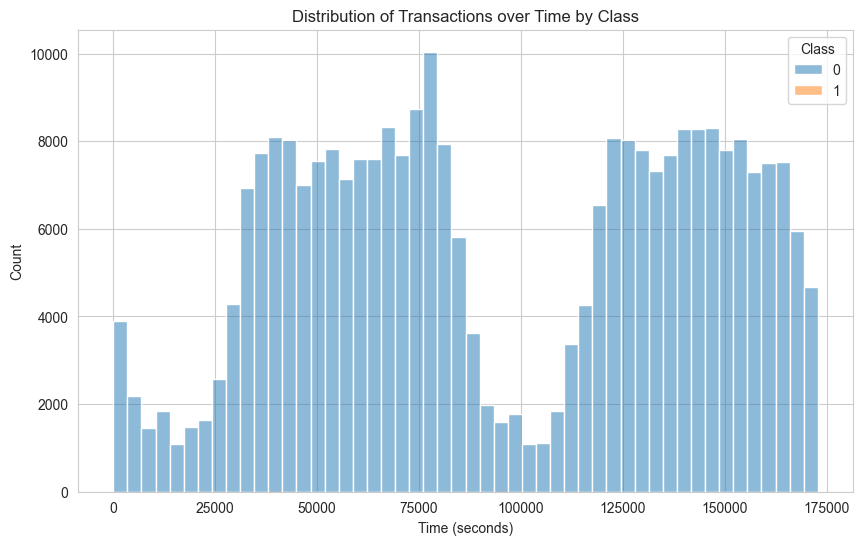

In [ ]:
# Analyze time distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Time', hue='Class', bins=50)
plt.title('Distribution of Transactions over Time by Class')
plt.xlabel('Time (seconds)')
plt.ylabel('Count')

* There are **743** steps, and every step has **at least 2** occurrences.

C:\Users\ilango\AppData\Local\Temp\ipykernel_12700\1707528972.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Class', data=df, palette='PuBu')


Text(0.5, 0, 'Class (0: Normal, 1: Fraud)')

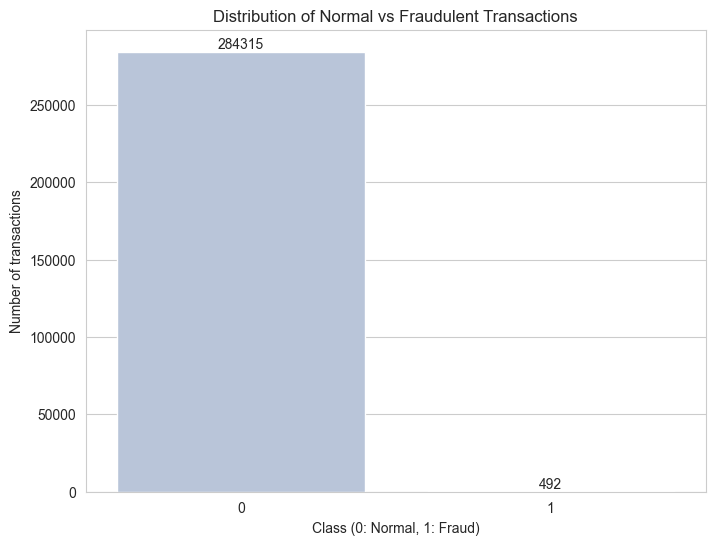

In [ ]:
# Plot class distribution
ax = sns.countplot(x='Class', data=df, palette='PuBu')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribution of Normal vs Fraudulent Transactions')
plt.ylabel('Number of transactions')
plt.xlabel('Class (0: Normal, 1: Fraud)')

* **Cash out** is **the most numerous** transaction type, followed by payment, cash in, transfer and debit types.

Text(0, 0.5, 'Count')

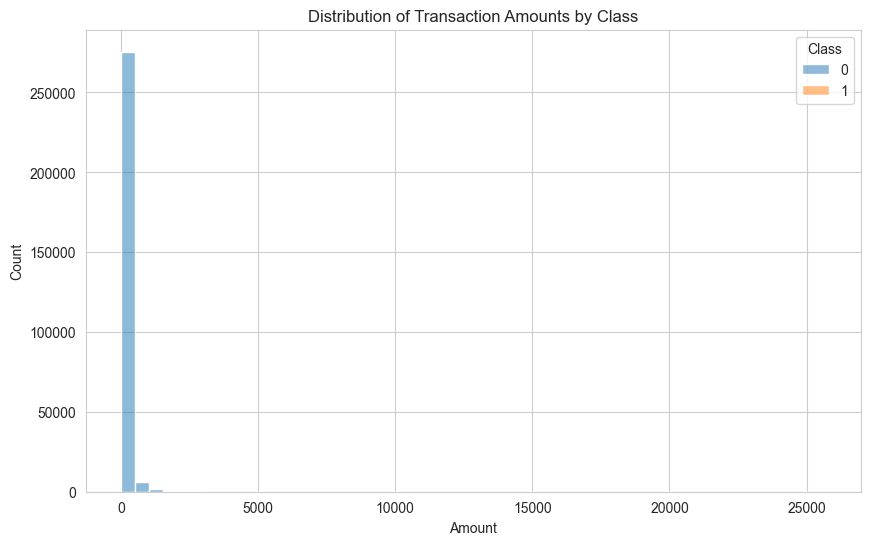

In [ ]:
# Plot amount distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Amount', hue='Class', bins=50)
plt.title('Distribution of Transaction Amounts by Class')
plt.xlabel('Amount')
plt.ylabel('Count')

* The distribution of transaction amounts is **right skewed**. 
* This indicates that most values are clustered around the left tail of the distribution, with the longer right tail. 
* (mode < median < mean)

In [ ]:
df['nameOrig'].value_counts()

* There are **6353307** initial customers, and every step has **at least 1** occurrence.

In [ ]:
sns.kdeplot(df['oldbalanceOrg'], linewidth=4)
plt.title('Distribution of transaction amount')

* The distribution of pre-transaction balances of the initial customers is **right skewed**.

In [ ]:
sns.kdeplot(df['newbalanceOrig'], linewidth=4)
plt.title('Distribution of transaction amount')

* The distribution of post-transaction balances of the initial customers is **right skewed**.

In [ ]:
df['nameDest'].value_counts()

* There are **2722362** recipients, and every step has **at least 1** occurrence.

In [ ]:
sns.kdeplot(df['oldbalanceDest'], linewidth=4)
plt.title('Distribution of transaction amount')

* The distribution of pre-transaction balances of the recipient is **right skewed**.

In [ ]:
sns.kdeplot(df['newbalanceDest'], linewidth=4)
plt.title('Distribution of transaction amount')

* The distribution of post-transaction balances of the recipient is **right skewed**.

In [ ]:
ax = sns.countplot(x='isFraud', data=df, palette='PuBu')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Count plot of fraud transaction')
plt.ylabel('Number of transactions')

del ax

* There are much **more non-fraudulent transactions** than fraudulent transactions.

<h2>
    <div style='background:steelblue'> 
    <font color='white'>
    <b>&nbsp; Bivariate data visualization</b>
    </font>
    </div>
</h2>

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(20,5))

sns.countplot(x='type', data=df, hue='isFraud', palette='PuBu', ax=ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container)
ax[0].set_title('Count plot of transaction type')
ax[0].legend(loc='best')
ax[0].set_ylabel('Number of transactions')

df2 = df.groupby(['type', 'isFraud']).size().unstack()
df2.apply(lambda x : round(x/sum(x)*100, 2), axis=1).plot(kind='barh', stacked=True, color=['lightsteelblue', 'steelblue'], ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container, label_type='center')
ax[1].set_title('Count plot of transaction type')
ax[1].legend(bbox_to_anchor=(1.05,1), loc='upper left')
ax[1].set_ylabel('Number of transactions')
ax[1].grid(axis='y')

* Fraudulent transactions only occur in debit and transfer types.

In [ ]:
df['quantity'] = pd.cut(df['amount'], 5, labels=['very low', 'low', 'moderate', 'high', 'very high'])

ax = sns.countplot(x='quantity', data=df, hue='isFraud', palette='PuBu')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Count plot of amount quantity')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.ylabel('Number of transactions')

* All fraudulent transactions fall into the category of very low amounts. 
* This suggests that in most cases, small transactions are more prone to fraudulent transactions.

In [ ]:
df1 = df[df['isFraud']==1]
df2 = df1['step'].value_counts().head(10)
ax = df2.plot(kind='bar', color='lightsteelblue')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Top 10 steps that often lead to fraudulent transactions')
plt.ylabel('Number of fraudulent transactions')
plt.xlabel('Step')
plt.grid(axis='x')

del ax, df2

* **Step 212** has the highest number of fraudulent transactions, 40 cases. 
* This indicates that Step 212 is the step that will most likely lead to fraudulent transactions.

In [ ]:
df['oldbalanceOrg_amt'] = pd.cut(df['oldbalanceOrg'], 5, labels=['very low', 'low', 'moderate', 'high', 'very high'])

ax = sns.countplot(x='oldbalanceOrg_amt', data=df, hue='isFraud', palette='PuBu')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Count plot of initial customers pre-transaction balance amount')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.ylabel('Number of transactions')
plt.xlabel('Initial customers pre-transaction balance amount')

* Initial customers with **very low pre-transaction balances** has the highest number of fraudulent transactions. 
* This means that initial customers with very low pre-transaction balances may be more likely to fall for a fraudulent transaction.

In [ ]:
df2 = df1['nameOrig'].value_counts().head(10)
ax = df2.plot(kind='bar', color='lightsteelblue')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Top 10 initial customers fall for a fraudulent transactions')
plt.ylabel('Number of fraudulent transactions')
plt.xlabel('Initial customers')
plt.grid(axis='x')

del ax, df2

* Initial customers are scammed of **at most one** for a fraudulent transaction.

In [ ]:
df2 = df1['nameDest'].value_counts().head(10)
ax = df2.plot(kind='bar', color='lightsteelblue')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Top 10 recipients highly involved in fraudulent transactions')
plt.ylabel('Number of fraudulent transactions')
plt.xlabel('Recipients')
plt.grid(axis='x')

del ax, df2

* Suspicious recipients only have a **maximum of 2** involved fraudulent transactions.

In [ ]:
df['oldbalanceDest_amt'] = pd.cut(df['oldbalanceDest'], 5, labels=['very low', 'low', 'moderate', 'high', 'very high'])

ax = sns.countplot(x='oldbalanceDest_amt', data=df, hue='isFraud', palette='PuBu')
for container in ax.containers:
    ax.bar_label(container)
plt.title('Count plot of recipients pre-transaction balance amount')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.ylabel('Number of transactions')
plt.xlabel('Recipient pre-transaction balance amount')

* Recipients with **very low pre-transaction balances** has the highest number of fraudulent transactions. 
* This implies that recipients with very low pre-transaction balances may be more susceptible to fraudulent transactions.

<h2>
    <div style='background:steelblue'> 
    <font color='white'>
    <b>&nbsp; Multivariate data visualization</b>
    </font>
    </div>
</h2>

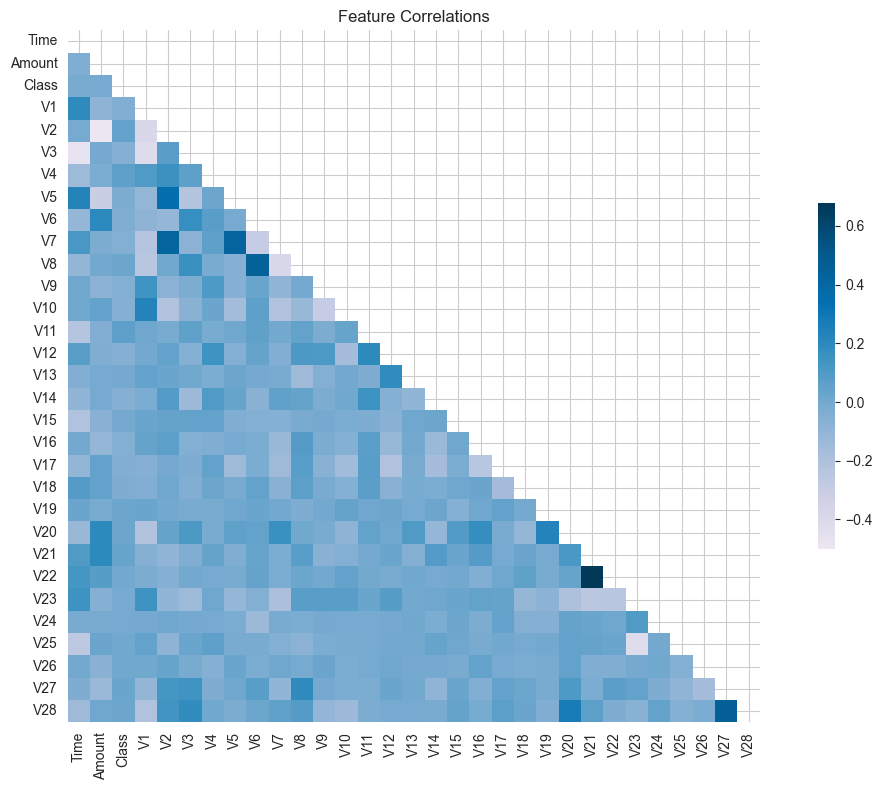

In [ ]:
# Calculate correlation matrix
cols_to_correlate = ['Time', 'Amount', 'Class'] + [f'V{i}' for i in range(1, 29)]
corr_matrix = df[cols_to_correlate].corr('spearman')

# Create correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='PuBu', center=0,
            mask=np.triu(np.ones_like(corr_matrix, dtype=bool)),
            fmt='.2f', square=True, cbar_kws={'shrink': .5})
plt.title('Feature Correlations')
plt.tight_layout()

* oldbalanceOrg and newbalanceOrig has **strong positive** relationship. 
* oldbalanceDest and newbalanceDest has **strong positive** relationship.
* oldbalanceOrg and amount has **weak positive** relationship.
* newbalanceOrig and amount has **moderate positive** relationship.

# <div style='background:darkblue'> <font color='white'> <b>&nbsp; Model Building</b> </font> </div>

In [ ]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Scale Amount and Time features
scaler = StandardScaler()
df[['Amount', 'Time']] = scaler.fit_transform(df[['Amount', 'Time']])

Due to the large dataset, Random Forest and Logistic Regression with balanced class weight are used to identify online payment fraud.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, roc_curve, auc, ConfusionMatrixDisplay

seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

X = df.copy()
X.drop(['Class'], axis=1, inplace=True)  # 'Class' is our target variable
y = df['Class']  # 1 for fraud, 0 for normal

# Stratified train-test split
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
for train_idx, test_idx in skfold.split(X,y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

sc = StandardScaler()
scaled_train = sc.fit_transform(X_train)
scaled_test = sc.transform(X_test)
X_train = pd.DataFrame(scaled_train, index=X_train.index, columns=X_train.columns)
X_test = pd.DataFrame(scaled_test, index=X_test.index, columns=X_test.columns)

X_train, y_train = RandomUnderSampler(sampling_strategy='majority').fit_resample(X_train, y_train)

In [ ]:
def model_comparison_evaluate(classifiers, X, y):
    print('K-Fold Cross-Validation:\n')
    for name, model in classifiers.items():
        print('{}:'.format(name))
        
        scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
        
        for score in scoring:
            scores = cross_val_score(model, X, y, scoring=score, cv=skfold, n_jobs=-1)
            print('Mean {} score: {:.3f} ({:.3f})'.format(score, scores.mean(), scores.std()))
            
        print('\n')

In [ ]:
classifiers = { 'Random Forest Classifier':RandomForestClassifier(class_weight='balanced', random_state=seed),
                'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=seed)
              }

In [ ]:
model_comparison_evaluate(classifiers, X_train, y_train)

K-Fold Cross-Validation:

Random Forest Classifier:
Mean accuracy score: 0.948 (0.016)
Mean accuracy score: 0.948 (0.016)
Mean precision score: 0.981 (0.018)
Mean precision score: 0.981 (0.018)
Mean recall score: 0.914 (0.025)
Mean recall score: 0.914 (0.025)
Mean f1 score: 0.946 (0.017)
Mean f1 score: 0.946 (0.017)
Mean roc_auc score: 0.981 (0.013)


Logistic Regression:
Mean accuracy score: 0.945 (0.009)
Mean precision score: 0.961 (0.017)
Mean recall score: 0.929 (0.026)
Mean f1 score: 0.944 (0.010)
Mean roc_auc score: 0.981 (0.013)


Logistic Regression:
Mean accuracy score: 0.945 (0.009)
Mean precision score: 0.961 (0.017)
Mean recall score: 0.929 (0.026)
Mean f1 score: 0.944 (0.010)
Mean roc_auc score: 0.977 (0.012)


Mean roc_auc score: 0.977 (0.012)




Random Forest Classifier:
               precision    recall  f1-score   support

Non-Fraud [0]       0.97      1.00      0.99     55346
    Fraud [1]       0.88      0.05      0.10      1615

     accuracy                           0.97     56961
    macro avg       0.93      0.53      0.54     56961
 weighted avg       0.97      0.97      0.96     56961
 



Text(0.5, 0, 'False Positive Rate')

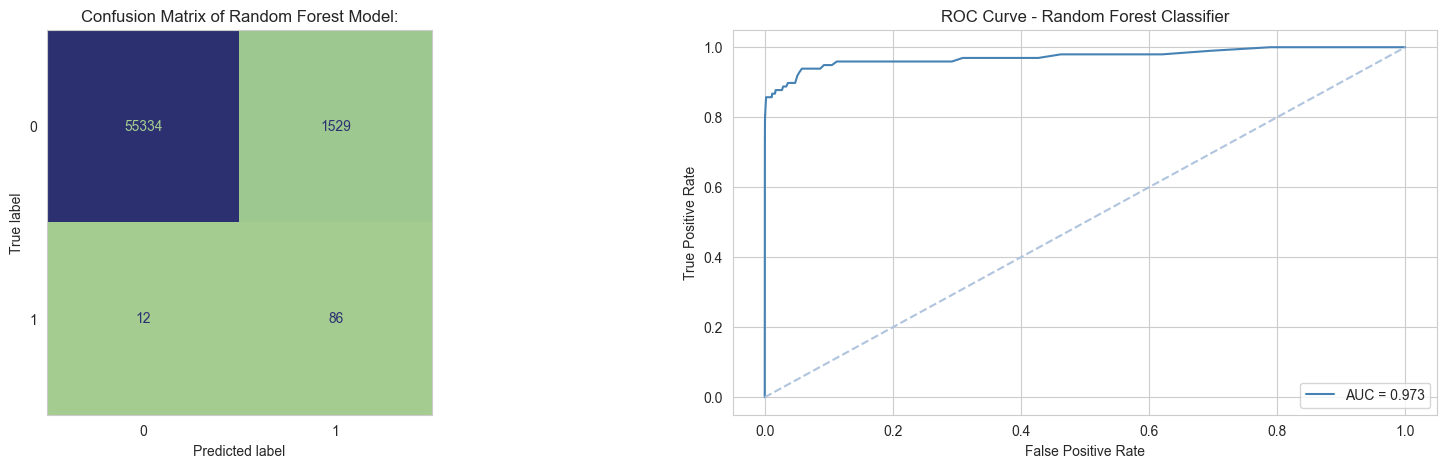

In [ ]:
model = RandomForestClassifier(class_weight='balanced', random_state=seed)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_score = model.predict_proba(X_test)[:,1]
print('Random Forest Classifier:')
print(classification_report(y_pred, y_test, labels=[0,1], target_names=['Non-Fraud [0]', 'Fraud [1]']), '\n')



fig, ax = plt.subplots(1, 2, figsize=(20,5))
ax[0].set_title('Confusion Matrix of Random Forest Model:')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=False, values_format='', cmap='crest', ax=ax[0])
ax[0].grid(False)



fpr, tpr, thresholds = roc_curve(y_test, y_pred_score)
roc_auc = auc(fpr, tpr)                       
ax[1].set_title('ROC Curve - Random Forest Classifier')
ax[1].plot(fpr, tpr, label = 'AUC = %0.3f' % roc_auc, c='steelblue')
ax[1].plot([0,1],[0,1],'--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')

* From the confusion matrix, 1,239,155 were correctly classified as non-fraudulent payments, and 31,726 people were misclassified as non-fraudulent payments.
* According to the confusion matrix, 1,639 payments were incorrectly labelled as fraud while 4 payments were correctly identified as fraud.

# <div style='background:darkblue'>  <font color='white'> <b>&nbsp; Conclusion</b> </font> </div>

* Random Forest obtains the highest score of all using K-fold cross-validation.
* The best performing model is **Random Forest** for identifying fraudulent and non-fraudulent payments, as the AUC is 0.999, which is close to 1. This means it has a good separability measure, and the model has an 99.9% chance of being able to distinguish between positive and negative classes..